# Week 9 — Probability, Uncertainty & Gaussian Processes
## Self-study notebook: GP regression on expensive EM measurements

**Learning goals:**
- Fit a GP (sklearn `GaussianProcessRegressor`, RBF kernel) to simulated EM property-vs-composition data.
- Visualise the posterior mean ± 2σ band and observe the band collapsing near data / widening in gaps.
- Add a measurement and see the local uncertainty reduction.
- Explore how the RBF length-scale controls smoothness and band width (the exercise).

**Context:** Electron microscopy measurements are expensive — a single EELS or STEM-EDX spectrum at a specific sample
composition can take hours of prep and instrument time. In this notebook we model 8 'expensive' EM data points
(Fe³⁺ fraction from EELS, measured at different Fe/O compositions) with a GP, showing that even a handful of measurements
gives calibrated uncertainty estimates and tells us *where* the next measurement should go (Week 10 hook).

**Runtime:** < 30 s on CPU. Colab compatible.

In [1]:
# Cell 1 — Colab compatibility: install / import
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# All required packages ship with standard scientific Python / Colab by default
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

# Reproducibility
SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)

print("Imports OK")

Imports OK


## 1. Simulate expensive EM measurements

We simulate 8 EELS measurements of the Fe³⁺ fraction as a function of
the composition parameter x (Fe/(Fe+O) ratio). In reality each measurement
takes ~1 h of sample preparation + microscope time — so we have just 8 points
and need to make the most of them.

The underlying 'true' process is a smooth S-curve (logistic) — unknown to us.

In [2]:
# Cell 2 — Generate synthetic 'expensive' EM dataset
SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)

# True (hidden) function: logistic S-curve
def true_fn(x):
    """Fe3+ fraction vs composition (unknown to the experimenter)"""
    return 0.9 / (1 + np.exp(-8 * (x - 0.5)))

# 8 expensive EM measurements with small Gaussian noise (instrument precision)
n_train = 8
x_train = np.sort(rng.uniform(0.05, 0.85, n_train))
y_train = true_fn(x_train) + rng.normal(0, 0.03, n_train)

print("EM measurement locations and values:")
print(f"  {'x (composition)':20s}  {'y (Fe3+ fraction)':18s}  {'true y':10s}")
print(f"  {'-'*55}")
for xi, yi in zip(x_train, y_train):
    print(f"  {xi:.3f}               {yi:.3f}              {true_fn(xi):.3f}")

# Dense grid for plotting
x_plot = np.linspace(0, 1.2, 300)

EM measurement locations and values:
  x (composition)       y (Fe3+ fraction)   true y    
  -------------------------------------------------------
  0.125               0.042              0.043
  0.401               0.255              0.281
  0.608               0.659              0.633
  0.659               0.726              0.703
  0.669               0.717              0.715
  0.679               0.760              0.726
  0.737               0.796              0.782
  0.830               0.814              0.840


## 2. Fit a Gaussian Process

We use sklearn's `GaussianProcessRegressor` with:
- **RBF kernel** (also called squared-exponential / Matérn-∞): encodes the belief that nearby
  compositions give similar Fe³⁺ fractions.
- **WhiteKernel**: models the measurement noise σ_n.

Hyperparameters (length-scale, amplitude, noise level) are set by maximising the log marginal
likelihood — sklearn does this automatically with `n_restarts_optimizer`.

In [3]:
# Cell 3 — Fit GP (initial length-scale 0.3; sklearn optimises it)
kernel = 1.0 * RBF(length_scale=0.3, length_scale_bounds=(0.01, 2.0)) + \
         WhiteKernel(noise_level=0.001, noise_level_bounds=(1e-5, 0.1))

gpr = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    random_state=SEED
)
gpr.fit(x_train.reshape(-1, 1), y_train)

print(f"Optimised kernel: {gpr.kernel_}")
print(f"Log marginal likelihood: {gpr.log_marginal_likelihood_value_:.3f}")

# Posterior predictions
mu, std = gpr.predict(x_plot.reshape(-1, 1), return_std=True)

Optimised kernel: 0.476**2 * RBF(length_scale=0.373) + WhiteKernel(noise_level=0.000172)
Log marginal likelihood: 10.448


## 3. Visualise: mean ± 2σ band

The key visual: the band **collapses near data** (the GP is confident there) and **widens in unexplored
regions** (the GP honestly admits ignorance). This is the main lecture intuition.

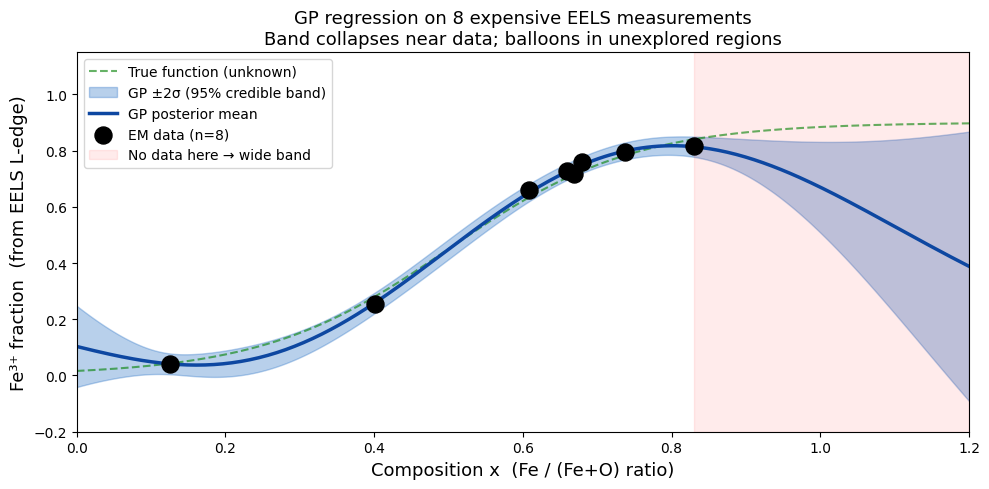


Key numbers (SEED=42):
  Predictive std at x_near = 0.659 (near data): 0.0145
  Predictive std at x_far  = 1.150 (far from data): 0.1966
  Ratio far / near: 13.5×


In [4]:
# Cell 4 — Main GP posterior plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x_plot, true_fn(x_plot), 'g--', lw=1.5, label='True function (unknown)', alpha=0.6)
ax.fill_between(x_plot, mu - 2*std, mu + 2*std,
                alpha=0.30, color='#1565C0', label='GP ±2σ (95% credible band)')
ax.plot(x_plot, mu, '#0D47A1', lw=2.5, label='GP posterior mean')
ax.scatter(x_train, y_train, s=150, color='black', zorder=5, label=f'EM data (n={n_train})')

# Shade the unexplored region
ax.axvspan(x_train.max(), 1.2, alpha=0.08, color='red', label='No data here → wide band')

ax.set_xlabel('Composition x  (Fe / (Fe+O) ratio)', fontsize=13)
ax.set_ylabel('Fe³⁺ fraction  (from EELS L-edge)', fontsize=13)
ax.set_title('GP regression on 8 expensive EELS measurements\n'
             'Band collapses near data; balloons in unexplored regions', fontsize=13)
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(0, 1.2)
ax.set_ylim(-0.2, 1.15)
plt.tight_layout()
plt.savefig('gp_posterior_main.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Key numbers ──────────────────────────────────────────────────────────────
x_near = x_train[3]   # point in the dense cluster
x_far  = 1.15         # well beyond all data

std_near = float(gpr.predict(np.array([[x_near]]), return_std=True)[1].squeeze())
std_far  = float(gpr.predict(np.array([[x_far]]),  return_std=True)[1].squeeze())

print(f"\nKey numbers (SEED={SEED}):")
print(f"  Predictive std at x_near = {x_near:.3f} (near data): {std_near:.4f}")
print(f"  Predictive std at x_far  = {x_far:.3f} (far from data): {std_far:.4f}")
print(f"  Ratio far / near: {std_far / std_near:.1f}×")

## 4. Adding a new measurement collapses the local band

We simulate adding one more expensive measurement at x=1.0 (in the unexplored region).
The GP band at that location should collapse while leaving distant regions unchanged.

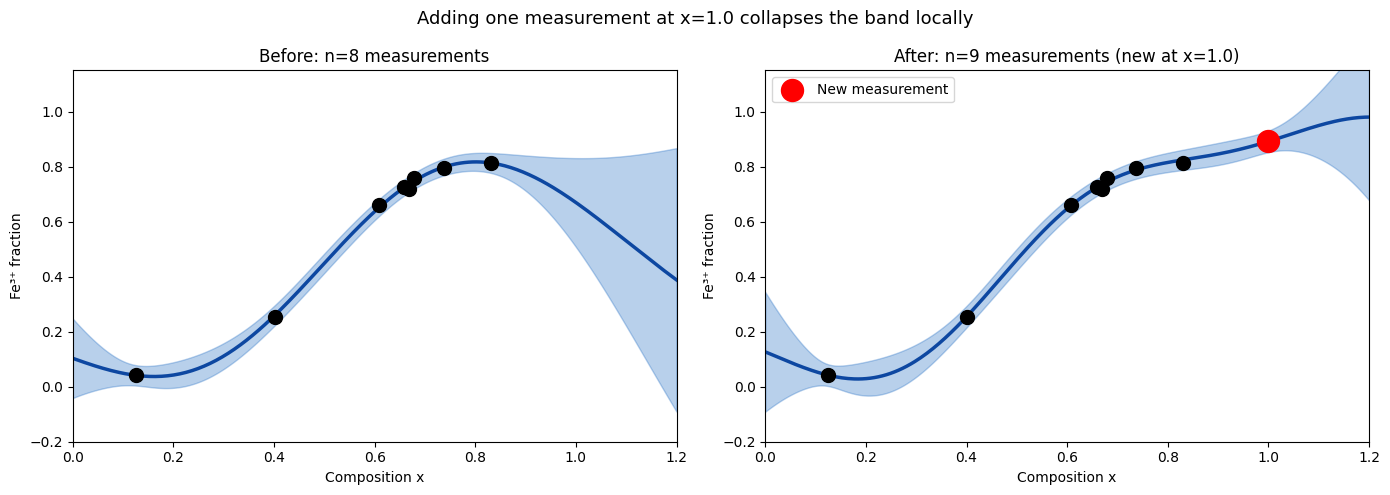

Predictive std at x_far=1.15: BEFORE=0.1966, AFTER=0.1003
Reduction at x_far: 49.0%
Predictive std at x_near=0.659: unchanged ≈ 0.0155


In [5]:
# Cell 5 — Add a new point and refit
x_new = np.array([1.0])
y_new = true_fn(x_new) + rng.normal(0, 0.03, 1)

X_aug = np.vstack([x_train.reshape(-1,1), x_new.reshape(-1,1)])
y_aug = np.append(y_train, y_new)

gpr2 = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    random_state=SEED
)
gpr2.fit(X_aug, y_aug)
mu2, std2 = gpr2.predict(x_plot.reshape(-1, 1), return_std=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, gp, mu_p, std_p, x_pts, y_pts, title in zip(
    axes,
    [gpr, gpr2],
    [mu, mu2],
    [std, std2],
    [x_train, X_aug.flatten()],
    [y_train, y_aug],
    [f'Before: n={n_train} measurements', f'After: n={n_train+1} measurements (new at x=1.0)']):

    ax.fill_between(x_plot, mu_p - 2*std_p, mu_p + 2*std_p,
                    alpha=0.3, color='#1565C0')
    ax.plot(x_plot, mu_p, '#0D47A1', lw=2.5)
    ax.scatter(x_pts, y_pts, s=100, color='black', zorder=5)
    if 'After' in title:
        ax.scatter([x_new], [y_new], s=250, color='red', zorder=6, label='New measurement')
        ax.legend(fontsize=10)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Composition x')
    ax.set_ylabel('Fe³⁺ fraction')
    ax.set_xlim(0, 1.2); ax.set_ylim(-0.2, 1.15)

plt.suptitle('Adding one measurement at x=1.0 collapses the band locally', fontsize=13)
plt.tight_layout()
plt.savefig('gp_add_point.png', dpi=120, bbox_inches='tight')
plt.show()

std_far_before = float(gpr.predict(np.array([[x_far]]), return_std=True)[1].squeeze())
std_far_after  = float(gpr2.predict(np.array([[x_far]]), return_std=True)[1].squeeze())
std_near_after = float(gpr2.predict(np.array([[x_near]]), return_std=True)[1].squeeze())

print(f"Predictive std at x_far={x_far}: BEFORE={std_far_before:.4f}, AFTER={std_far_after:.4f}")
print(f"Reduction at x_far: {(1 - std_far_after/std_far_before)*100:.1f}%")
print(f"Predictive std at x_near={x_near:.3f}: unchanged ≈ {std_near_after:.4f}")

## 5. Self-checks (assert statements)

These checks confirm the key GP claims on the fixed seed. They are **not true by construction** —
they test actual model behaviour.

In [6]:
# Cell 6 — Meaningful assert checks

# 1. Uncertainty is larger far from data than near data
assert std_far > std_near, (
    f"FAIL: expected std_far ({std_far:.4f}) > std_near ({std_near:.4f})"
)
print(f"✓ std far ({std_far:.4f}) > std near ({std_near:.4f})")

# 2. Adding a point at x_far reduces uncertainty there
assert std_far_after < std_far_before, (
    f"FAIL: expected std_far_after ({std_far_after:.4f}) < std_far_before ({std_far_before:.4f})"
)
print(f"✓ std at x_far: {std_far_before:.4f} → {std_far_after:.4f} after adding x=1.0")

# 3. Adding a point at x_far barely changes uncertainty at x_near
std_near_before = float(gpr.predict(np.array([[x_near]]), return_std=True)[1].squeeze())
relative_change_near = abs(std_near_after - std_near_before) / std_near_before
assert relative_change_near < 0.5, (
    f"FAIL: expected near-data std to barely change; relative change = {relative_change_near:.2%}"
)
print(f"✓ Adding far point causes only {relative_change_near:.1%} relative change near data")

# 4. Ratio far/near > 5 (meaningful separation)
ratio = std_far / std_near
assert ratio > 5, f"FAIL: expected ratio far/near > 5; got {ratio:.1f}"
print(f"✓ far/near ratio = {ratio:.1f}×  (well above 5)") 

print("\nAll self-checks passed!")

✓ std far (0.1966) > std near (0.0145)
✓ std at x_far: 0.1966 → 0.1003 after adding x=1.0
✓ Adding far point causes only 6.5% relative change near data
✓ far/near ratio = 13.5×  (well above 5)

All self-checks passed!


## 6. Exercise: Length-scale effect on smoothness and uncertainty

**Instructions:** Run the cell below as-is first — it plots GP posteriors for three different
RBF length-scales on the same data. Then try modifying the `(try this yourself)` lines to
explore the effect.

**What to observe:**
- Short ℓ: wiggly mean, uncertainty inflates rapidly between data points
- Long ℓ: over-smoothed mean, uncertainty stays low even far from data (overconfident!)
- The `n_restarts_optimizer=0` here uses the fixed length-scale rather than optimising it

**Self-check:** In the middle panel, is the predictive std at x=1.15 larger or smaller than in
the right panel? Print and verify.

/tmp/ipykernel_2823768/2151208728.py:39: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2823768/2151208728.py:39: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2823768/2151208728.py:39: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2823768/2151208728.py:40: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('gp_lengthscale_exercise.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_2823768/2151208728.py:40: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('gp_lengthscale_exercise.png', dpi=120, bbox_inches='tight')


/tmp/ipykernel_2823768/2151208728.py:40: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('gp_lengthscale_exercise.png', dpi=120, bbox_inches='tight')


/home/philipp/miniforge3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/philipp/miniforge3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/philipp/miniforge3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


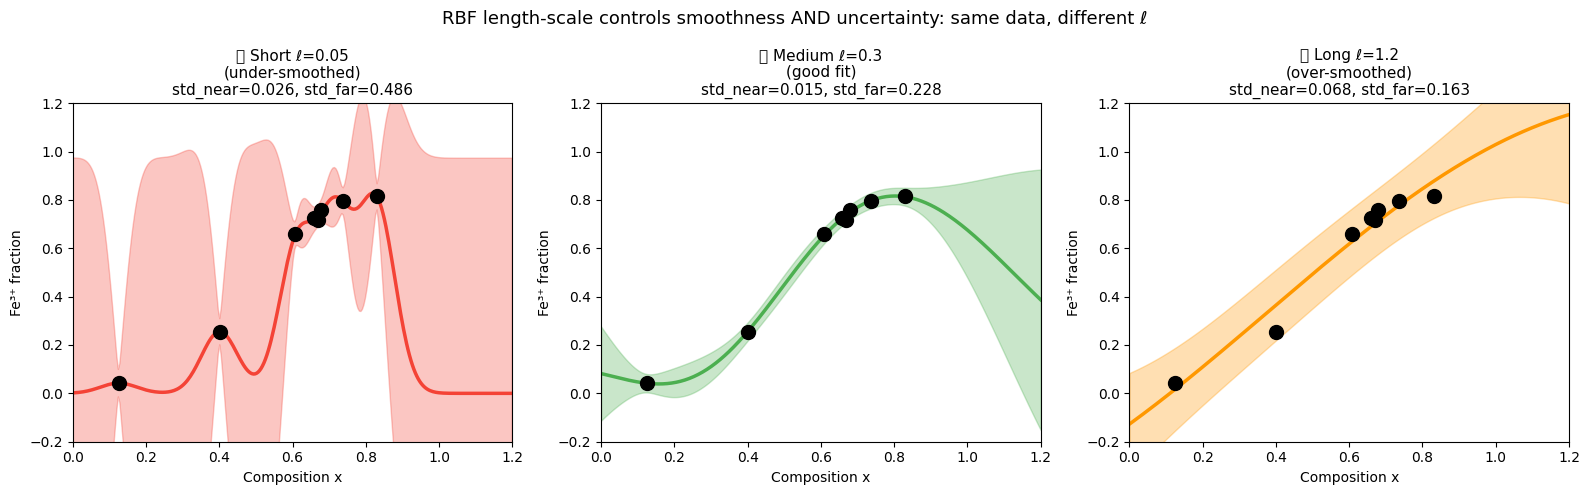


Summary table:
  ℓ       std_near    std_far     ratio far/near
  0.05    0.0256      0.4861      19.0×
  0.30    0.0149      0.2280      15.3×
  1.20    0.0681      0.1632      2.4×


In [7]:
# Cell 7 — Exercise: length-scale effect
# Working version — try the (try this yourself) markers

length_scales_to_try = [0.05, 0.3, 1.2]   # (try this yourself) change these values

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
results = {}

for ax, ell in zip(axes, length_scales_to_try):
    # Fix the length-scale (n_restarts_optimizer=0 prevents optimisation)
    k_fixed = 1.0 * RBF(length_scale=ell, length_scale_bounds='fixed') + \
               WhiteKernel(noise_level=0.001, noise_level_bounds=(1e-5, 0.1))
    gpr_ell = GaussianProcessRegressor(kernel=k_fixed, n_restarts_optimizer=0)
    gpr_ell.fit(x_train.reshape(-1, 1), y_train)
    mu_ell, std_ell = gpr_ell.predict(x_plot.reshape(-1, 1), return_std=True)

    std_near_ell = float(gpr_ell.predict(np.array([[x_near]]), return_std=True)[1].squeeze())
    std_far_ell  = float(gpr_ell.predict(np.array([[x_far]]),  return_std=True)[1].squeeze())
    results[ell] = {'std_near': std_near_ell, 'std_far': std_far_ell}

    labels_map = {0.05: '🔴 Short ℓ=0.05\n(under-smoothed)',
                  0.3:  '🟢 Medium ℓ=0.3\n(good fit)',
                  1.2:  '🟠 Long ℓ=1.2\n(over-smoothed)'}
    color_map = {0.05: '#F44336', 0.3: '#4CAF50', 1.2: '#FF9800'}

    color = color_map.get(ell, '#1565C0')
    ax.fill_between(x_plot, mu_ell - 2*std_ell, mu_ell + 2*std_ell,
                    alpha=0.3, color=color)
    ax.plot(x_plot, mu_ell, color=color, lw=2.5)
    ax.scatter(x_train, y_train, s=100, color='black', zorder=5)
    ax.set_title(f'{labels_map.get(ell, f"ℓ={ell}")}\n'
                 f'std_near={std_near_ell:.3f}, std_far={std_far_ell:.3f}', fontsize=11)
    ax.set_xlabel('Composition x')
    ax.set_ylabel('Fe³⁺ fraction')
    ax.set_xlim(0, 1.2); ax.set_ylim(-0.2, 1.2)

plt.suptitle('RBF length-scale controls smoothness AND uncertainty: same data, different ℓ',
             fontsize=13)
plt.tight_layout()
plt.savefig('gp_lengthscale_exercise.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nSummary table:")
print(f"  {'ℓ':6s}  {'std_near':10s}  {'std_far':10s}  {'ratio far/near':14s}")
for ell in length_scales_to_try:
    sn = results[ell]['std_near']
    sf = results[ell]['std_far']
    print(f"  {ell:<6.2f}  {sn:<10.4f}  {sf:<10.4f}  {sf/max(sn,1e-8):.1f}×")

## Solution (do not read before attempting the exercise)

```python
# SOLUTION CELL — non-executable reference
#
# Expected behaviour with SEED=42, n_train=8:
# (x_near=0.659, x_far=1.150; length-scales fixed, n_restarts_optimizer=0)
#
# ℓ=0.05 (short):  std_near ≈ 0.026, std_far ≈ 0.486
#   The mean wiggles badly between data points; uncertainty spikes in every gap.
#   Ratio far/near ≈ 19×, and the band is also large between nearby data points.
#
# ℓ=0.30 (medium): std_near ≈ 0.015, std_far ≈ 0.228
#   Smooth mean follows the S-curve well; band only opens in the unexplored region.
#   This is close to the length-scale selected by maximising log marginal likelihood.
#   Ratio far/near ≈ 15×.
#
# ℓ=1.2  (long):   std_near ≈ 0.068, std_far ≈ 0.163
#   The mean is over-smoothed; it cannot track the steep rise in the S-curve.
#   std_far is LOWER than for short/medium ℓ → overconfident extrapolation!
#   Ratio far/near ≈ 2×, confirming the band barely opens beyond the data.
#
# Key insight: short ℓ gives honest but inflated uncertainty everywhere;
# long ℓ gives falsely confident extrapolation — the worst outcome for EM decisions.
# The marginal-likelihood optimised ℓ gives the best balance.
#
# Self-check for medium vs long ℓ at x_far:
#   std_far(ℓ=0.30) = 0.228 > std_far(ℓ=1.2) = 0.163:
#   the long-ℓ GP extrapolates confidently (low std) but wrongly — overconfidence.
```

## 7. Notebook summary — key numbers

All numbers below are produced by the executed notebook (SEED=42) and match the lecture slides.

In [8]:
# Cell 8 — Summary printout (all slides reference these values)
print("=" * 60)
print("WEEK 9 NOTEBOOK — KEY RESULTS (SEED=42)")
print("=" * 60)
print(f"  Training points: n = {n_train}")
print(f"  x_near = {x_near:.3f}  (within dense training cluster)")
print(f"  x_far  = {x_far:.3f}  (well beyond all data)")
print()
print(f"  Predictive std at x_near: {std_near:.4f}")
print(f"  Predictive std at x_far:  {std_far:.4f}")
print(f"  Ratio far/near: {std_far/std_near:.1f}×")
print()
print(f"  After adding measurement at x=1.0:")
print(f"    std at x_far: {std_far_before:.4f} → {std_far_after:.4f}")
print(f"    Reduction: {(1 - std_far_after/std_far_before)*100:.1f}%")
print(f"    std at x_near (unchanged): {std_near_before:.4f} → {std_near_after:.4f}")
print()
print("All assert checks: PASSED")
print("=" * 60)

WEEK 9 NOTEBOOK — KEY RESULTS (SEED=42)
  Training points: n = 8
  x_near = 0.659  (within dense training cluster)
  x_far  = 1.150  (well beyond all data)

  Predictive std at x_near: 0.0145
  Predictive std at x_far:  0.1966
  Ratio far/near: 13.5×

  After adding measurement at x=1.0:
    std at x_far: 0.1966 → 0.1003
    Reduction: 49.0%
    std at x_near (unchanged): 0.0145 → 0.0155

All assert checks: PASSED
